## Tasks 
1. Data loading and Preprocessing =>done
2. visualize it =>done 
3. break it into train and test=>will probably use cross validation at later steps =>done
4. reshape the data=>flatten it=>done
5. subtract mean to the data sets so it is centred aroung 0=>can remove common backgrounds,easier optimization=>done
6. predict the labels using a linear clf=>dome
7. write softmax fxn=>done
8. find cross entropy loss in the fxn =>done
9. optimize it using sgd/mini batch=>done
10. get the loss curve with no of iterations=>done
11. use cross validation to find where do we get te best accuaracy on val set with both data and regularization loss=>done
12. get the templates of each classes after training=>done
13. lastly check it on the cifar dataset=>done

In [1]:
#import libraries 
%matplotlib inline
import numpy as np 
import matplotlib.pyplot as plt 
import torchvision
from torchvision import datasets , transforms

In [2]:
#Import the data

#tranformation 
transform = transforms.Compose([transforms.ToTensor(),])
#training set
trainset = torchvision.datasets.CIFAR10(root="../data/",transform=transform,train=True) 

#testing set
testset = torchvision.datasets.CIFAR10(root="../data/",transform=transform,train=False) 


In [51]:
X_train = [] 
y_train = [] 

#appending the trainset into the list 
for image,label in trainset: 
    X_train.append(image.numpy())
    y_train.append(label)

#converting the list to numpy array 

X_train = np.array(X_train) 
y_train = np.array(y_train) 

#now for the training set 

X_test = [] 
y_test = [] 

for image,label in testset: 
    X_test.append(image.numpy())
    y_test.append(label) 
    
X_test = np.array(X_test) 
y_test = np.array(y_test) 


In [52]:
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 3, 32, 32)
Training labels shape:  (50000,)
Test data shape:  (10000, 3, 32, 32)
Test labels shape:  (10000,)


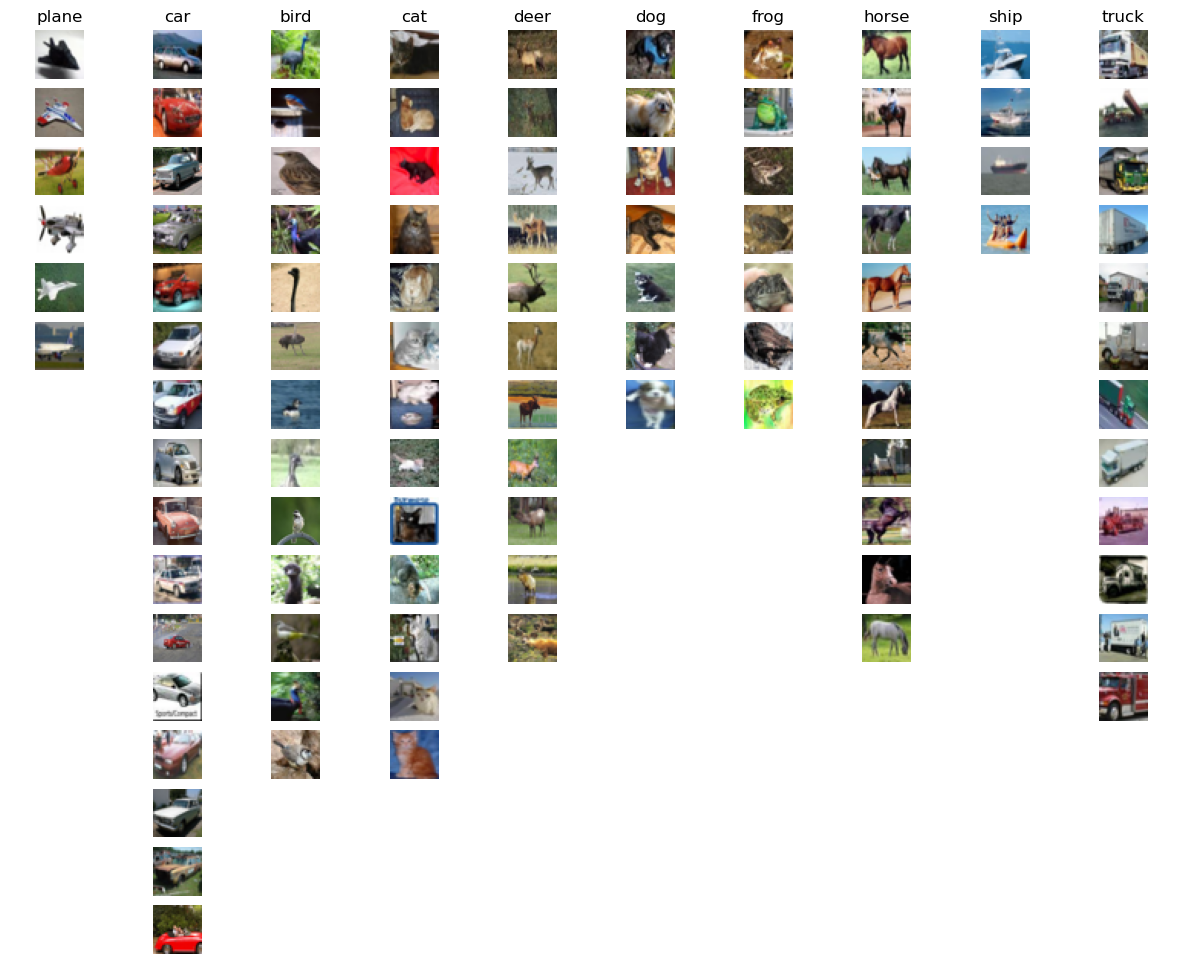

In [53]:
# visualize the data
classes_names = ['plane', 'car', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

classes = {i : [] for i in range(10)}

# lets iterate for first 100 examples
for i in range(100):
    classes[y_train[i]].append(X_train[i].transpose(1, 2, 0))

# Number of rows = maximum images in any class
rows = max(len(v) for v in classes.values())

fig, ax = plt.subplots(rows, 10, figsize=(15, 12))

for col in range(10):
    ax[0, col].set_title(classes_names[col])

    for row in range(rows):
        ax[row, col].axis("off")

        if row < len(classes[col]):
            ax[row, col].imshow(classes[col][row])
        
plt.show()

In [54]:
#Flatten the images

X_train = X_train.reshape(X_train.shape[0],-1)
X_test  = X_test.reshape(X_test.shape[0],-1)


X_train.shape

(50000, 3072)

In [55]:
#Subtract the mean 
X_train-=np.mean(X_train,axis=0)

In [56]:
#completed till here 
"""
Data loading
Visualizing a few CIFAR-10 images
Flattening the images
Mean subtraction (using the training mean)

"""

'\nData loading\nVisualizing a few CIFAR-10 images\nFlattening the images\nMean subtraction (using the training mean)\n\n'

In [57]:
W = 0.01*np.random.randn(X_train.shape[1],10)
b = np.zeros(10)

In [58]:
scores = X_train@W + b

In [59]:
scores

array([[-0.00617512,  0.01684573, -0.12609746, ...,  0.21221335,
        -0.05444911, -0.07954091],
       [-0.1143055 , -0.13904423, -0.19762718, ...,  0.11308162,
         0.09453584,  0.005491  ],
       [ 0.00654157, -0.0374363 ,  0.00847202, ..., -0.3528789 ,
         0.24493508,  0.06806517],
       ...,
       [-0.01136763, -0.0294715 , -0.03502487, ..., -0.1324568 ,
         0.04076992,  0.00567155],
       [ 0.03024138, -0.2923981 ,  0.19639057, ..., -0.19072015,
         0.08179763, -0.12574631],
       [ 0.06378803, -0.01908883, -0.04619681, ..., -0.09210921,
         0.01463315,  0.09400637]])

In [60]:
#we will be writing softmax in two ways one in naive way using loops and one using np to see the time need in each

In [61]:
def softmax_loss_naive(W, b, X, y, reg):
    """
    Inputs
    - W: shape (D, C)
    - b: shape (C,)
    - X: shape (N, D)
    - y: shape (N,)
    - reg: regularization strength

    Returns
    - loss: scalar
    - dW: shape (D, C)
    - db: shape (C,)
    """

    loss = 0.0
    dW = np.zeros_like(W)
    db = np.zeros_like(b)

    num_train = X.shape[0]
    num_classes = W.shape[1]

    # b is broadcasted to every row
    scores = X @ W + b

    for i in range(num_train):
        shifted_scores = scores[i] - np.max(scores[i])

        exp_scores = np.exp(shifted_scores)
        probs = exp_scores / np.sum(exp_scores)

        loss += -np.log(probs[y[i]])

        for j in range(num_classes):
            ds = probs[j]

            if j == y[i]:
                ds -= 1

            # ds_j * x_i
            dW[:, j] += ds * X[i]

            # ds_j * 1, because ds_j / db_j = 1
            db[j] += ds

    loss /= num_train
    dW /= num_train
    db /= num_train

    # Usually regularize W, not b
    loss += reg * np.sum(W * W)
    dW += 2 * reg * W

    return loss, dW, db

In [62]:
def softmax_np(W, b, X, y, reg):
    """
    Inputs
    - W: shape (D, C)
    - b: shape (C,)
    - X: shape (N, D)
    - y: shape (N,)
    - reg: regularization strength

    Returns
    - loss: scalar
    - dW: shape (D, C)
    - db: shape (C,)
    """

    num_train = X.shape[0]

    # Forward pass
    scores = X @ W + b
    scores -= np.max(scores, axis=1, keepdims=True)

    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    correct_probs = probs[np.arange(num_train), y]
    loss = -np.mean(np.log(correct_probs))

    # Backward pass
    dscores = probs.copy()
    dscores[np.arange(num_train), y] -= 1
    dscores /= num_train

    dW = X.T @ dscores
    db = np.sum(dscores, axis=0)

    # Regularization
    loss += reg * np.sum(W * W)
    dW += 2 * reg * W

    return loss, dW, db

In [85]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
import time
tic = time.time()
loss_naive, grad_w,grad_b = softmax_loss_naive(W, b,X_train, y_train, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))


tic = time.time()
loss_vectorized, grad_w,grad_b = softmax_np(W, b, X_train, y_train, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


Naive loss: 2.304786e+00 computed in 2.376109s
Vectorized loss: 2.304786e+00 computed in 2.281319s


In [86]:
class SoftmaxClassifier(): 
    def __init__(self): 
        self.W=None 
        self.b=None 

    def train(self,X,y,learning_rate=1e-7,reg=1e4,num_iters=10000,batch_size=64): 
        #Training using mini batch 

        num_train = X.shape[0] 
        num_features  = X.shape[1] 
        num_classes = 10 

        #Initialize W and b if not till yet 
        if self.W is None: 
            self.W = 0.001 * np.random.randn(num_features, num_classes)
        if self.b is None:
             self.b = np.zeros(num_classes) 


        #list for loss history 
        loss_history=[] 

        #iterate through the X_train set num_iters time with randomly selected batches
        for interation in range(num_iters): 

            #sample a mini_batch 
            batch_indices = np.random.choice(num_train,batch_size,replace=True)

            X_batch =  X[batch_indices] 
            y_batch =  y[batch_indices] 

            loss,dW,db = softmax_np(self.W,self.b,X_batch,y_batch,reg) 

            loss_history.append(loss)

            # 3. Update parameters
            self.W -= learning_rate * dW
            self.b -= learning_rate * db

        return loss_history
        
    def predict(self, X):
        """
        Predict class labels.

        X: shape (N, D)
        returns: shape (N,)
        """

        scores = X @ self.W + self.b

        y_pred = np.argmax(scores, axis=1)

        return y_pred
        
        

In [99]:
learning_rates = [
    7.5e-7,
    1e-6,
    1.25e-6,
    1.5e-6,
    2e-6
]

regularization_strengths = [
    300,
    500,
    750,
    1000,
    1500,
    2000
]

In [100]:
num_iters = 1000
batch_size = 200

In [101]:
loss_histories = {}

for lr in learning_rates:
    for reg in regularization_strengths:
        model = SoftmaxClassifier()

        loss_history = model.train(
            X_train,
            y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=1000,
            batch_size=200
        )

        loss_histories[(lr, reg)] = loss_history

In [95]:
clf = SoftmaxClassifier() 
loss_history = clf.train(X_train,
    y_train,
    learning_rate=1e-6,
    reg=1e4,
    num_iters=1500,
    batch_size=200)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

In [104]:
train_accuracy = np.mean(y_train_pred == y_train)
test_accuracy = np.mean(y_test_pred == y_test)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 0.24392
Test accuracy: 0.0999


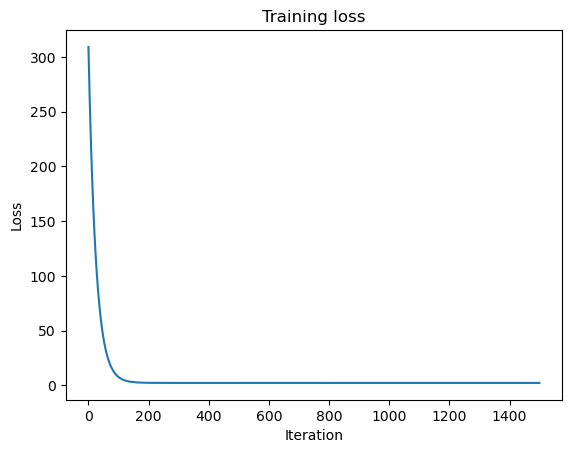

In [97]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

In [98]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

print(X_train.dtype, X_test.dtype)

print(np.min(y_train), np.max(y_train))
print(np.min(y_test), np.max(y_test))

print(loss_history[0], loss_history[-1])

(50000, 3072) (10000, 3072)
(50000,) (10000,)
float32 float32
0 9
0 9
309.1570931657277 2.302564055967351
